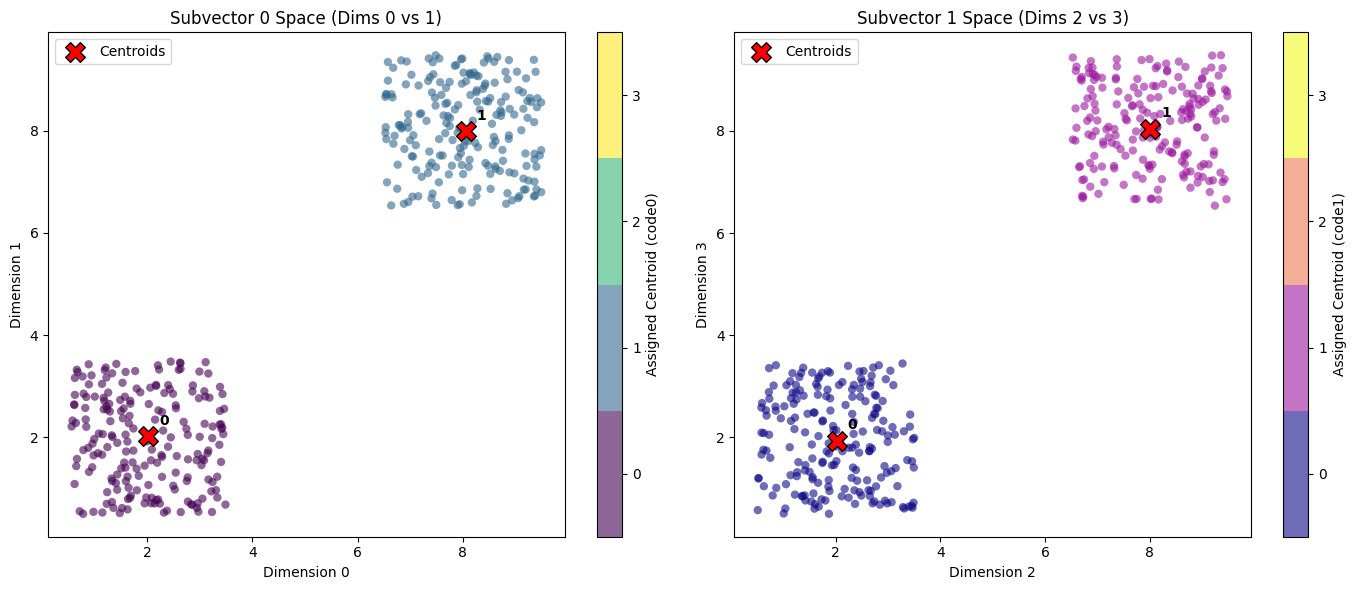

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data generated by the C test
df_vecs = pd.read_csv('pq_vectors.csv')
df_cents = pd.read_csv('pq_centroids.csv')

# Setup a 1x2 grid for our two subvectors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# We know we have 4 centroids per subvector (k* = 4)
k_star = 4

# Create discrete colormaps with exactly 4 distinct colors
cmap_sub0 = plt.get_cmap('viridis', k_star)
cmap_sub1 = plt.get_cmap('plasma', k_star)

# ---------------------------------------------------------
# Plot Subvector 0 space
# ---------------------------------------------------------
# Set vmin and vmax to center the colors on the integers 0, 1, 2, 3
scatter1 = ax1.scatter(df_vecs['x1'], df_vecs['y1'], c=df_vecs['code0'], 
                       cmap=cmap_sub0, vmin=-0.5, vmax=k_star-0.5, 
                       alpha=0.6, edgecolor='none')

# Filter and plot centroids for subvector 0
cents0 = df_cents[df_cents['subvector_idx'] == 0]
ax1.scatter(cents0['cx'], cents0['cy'], c='red', marker='X', s=200, edgecolor='black', label='Centroids')

# Annotate the centroid IDs
for _, row in cents0.iterrows():
    ax1.annotate(f"{int(row['centroid_idx'])}", (row['cx'], row['cy']), 
                 xytext=(8, 8), textcoords='offset points', weight='bold')

ax1.set_title('Subvector 0 Space (Dims 0 vs 1)')
ax1.set_xlabel('Dimension 0')
ax1.set_ylabel('Dimension 1')
ax1.legend()

# Add colorbar with explicit discrete ticks
fig.colorbar(scatter1, ax=ax1, ticks=range(k_star), label='Assigned Centroid (code0)')

# ---------------------------------------------------------
# Plot Subvector 1 space
# ---------------------------------------------------------
scatter2 = ax2.scatter(df_vecs['x2'], df_vecs['y2'], c=df_vecs['code1'], 
                       cmap=cmap_sub1, vmin=-0.5, vmax=k_star-0.5, 
                       alpha=0.6, edgecolor='none')

# Filter and plot centroids for subvector 1
cents1 = df_cents[df_cents['subvector_idx'] == 1]
ax2.scatter(cents1['cx'], cents1['cy'], c='red', marker='X', s=200, edgecolor='black', label='Centroids')

# Annotate the centroid IDs
for _, row in cents1.iterrows():
    ax2.annotate(f"{int(row['centroid_idx'])}", (row['cx'], row['cy']), 
                 xytext=(8, 8), textcoords='offset points', weight='bold')

ax2.set_title('Subvector 1 Space (Dims 2 vs 3)')
ax2.set_xlabel('Dimension 2')
ax2.set_ylabel('Dimension 3')
ax2.legend()

# Add colorbar with explicit discrete ticks
fig.colorbar(scatter2, ax=ax2, ticks=range(k_star), label='Assigned Centroid (code1)')

plt.tight_layout()
plt.show()